# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 30     |  |
| :-------------|:-------------|
| Bruno Schouten| 6577423 |
| Damien Vogelpoel| 6438431 |
| Tijn Derks| 6530036 |
| Planning Groep:      | 11:22  |
|---|---|
| Condensator af | 1230 |
| Sensor af | 1530 |
| groep aanwezig 1| 1045-1230 |
| groep aanwezig 2| 1330-1730 |
| Pauze 1| 1230-1330 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.

<img src="PlaatSchets.png" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np
#parameters
A = 0.105**2 #opppervlak in meter
d = 1.5*10**-3#afstand in meter
epsilon0 = 8.854 * 10**-12
espr_karton = 2.2 #relatieve permitiviteit karton zit tussen 2.2 en 3.8, dus gemiddeld 3
epsilon_karton = epsilon0 * espr_karton 
def vlakkeplaat(eps,A,d):
    C = eps*A/d 
    return C

C = vlakkeplaat(epsilon_karton,A,d)
print(C)

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

1.4316917999999997e-10


In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

C = [vlakkeplaat(epsilon_karton,A,d)]


print(f"Berekende capaciteit plaatcondensator groep 30 is {C[0]:.1e} pF")



Berekende capaciteit plaatcondensator groep 30 is 1.4e-10 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](IMG_2026.png)
![scope meting 2](IMG_2029.png)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit (pF)   | Berekend Voltage (V) | Gemeten Voltage (V) | Gemeten capaciteit (pF)   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 30| 140 | 0.36 | .55 |120 |

Binnen meetonzekerheid

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](IMG_2032.png)


## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een sensor maken die de hoeveelheid water tussen twee platen meet, en uit de metingen de neerslag in ml/uur meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](IMG_2033.png)

In [3]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.

#parameters
A= 0.15*0.1#m^2
d= 5e-3#m



##### Meting 1

Relative permitivity sponge: 12.77
Avg. distance between plates: 4.40 mm


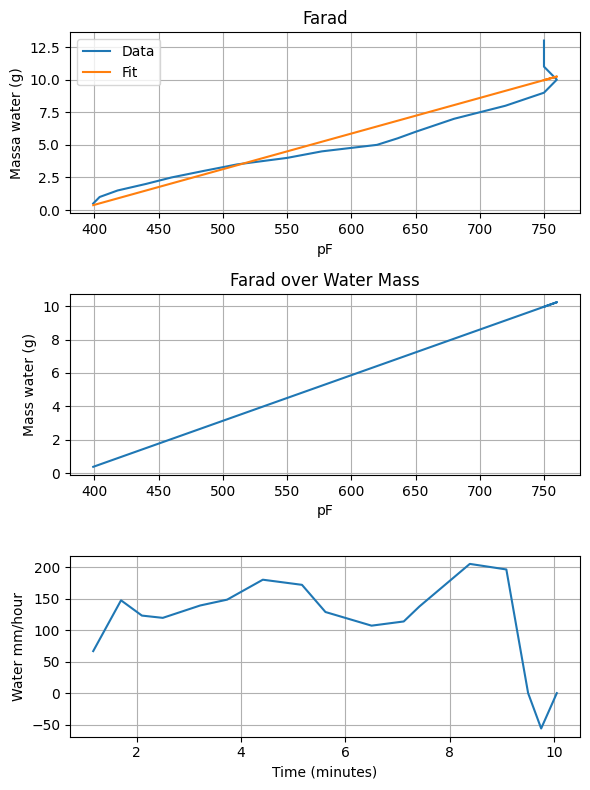

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

epsilon0=8.854e-12# permittiviteit van vacuum (F/m)

# Eerste meetreeksen

dml=np.array([0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5,1.0,1.0,1.0,1.0,1.0,1.0,1.0])
Mass=np.cumsum(dml)/1000

Farad=np.array([399,404,418,440,460,485,511,550,577,620,636,650,680,720,750,760,750,750,750])*1e-12

Time=np.array([
    1.167,
    1.700,
    2.100,
    2.500,
    3.217,
    3.733,
    4.417,
    5.167,
    5.617,
    6.500,
    7.117,
    7.417,
    8.383,
    9.083,
    9.500,
    9.750,
    10.050,
    10.333,
    10.600
])*60

# CONSTANTS
height=0.15# Meter
width=0.10# Meter
thickness=0.005# Meter

Area=height*width

# Epsilon values
eps0=epsilon0
eps_S=eps0*20
eps_W=eps0*80.1# Op kamertemperatuur, K=293

Max_Volume_Constant=0.85# Max percentage that the sponge can be saturated with water

# Setup values
C_ref=100e-12# Reference condensator in F
V_ref=5# Reference input voltage in V

def FaradToVolatge(Farad):
    return (Farad*V_ref)/(Farad+C_ref)

Voltages=FaradToVolatge(Farad)

# CALCULATE THE RIGHT FIT
def VoltageMassFit(Voltage,eps_S_fit,thickness_fit):    # Calculates amount of water present in the sponge
    Volume_fit=Area*thickness_fit
    Mass_max_water_fit=Volume_fit*1000*Max_Volume_Constant  # Maximum mass of water sponge can take on

    term1=Mass_max_water_fit/(Max_Volume_Constant*eps_W)
    term2=(thickness_fit/Area)*((Voltage*C_ref)/(V_ref-Voltage))-(eps_S_fit*epsilon0)

    mass=term1*term2
    return mass

lower_bounds=[1,0.001]
upper_bounds=[100,0.01]

popt,pcov=curve_fit(VoltageMassFit,Voltages,Mass,p0=[20,0.005],bounds=(lower_bounds,upper_bounds))

def VoltageFarad(Voltages):
    Farad=(Voltages*C_ref)/(V_ref-Voltages)
    return Farad

# Calculating rate of change
Top_Area=width*thickness
dt=int(2)# Measurements

Masses=VoltageMassFit(Voltages,*popt)

def mm_water(d_Mass):
    return (d_Mass/Top_Area)

# Calculate mass differences between points
dMass=np.zeros(len(Masses)-dt)
for index in range(len(Masses)-dt):# Calculates difference in mass between two points
    dMass[index]=Masses[index+dt]-Masses[index]

dTimes=np.zeros(len(Time)-dt)
for index in range(len(Time)-dt):
    dTimes[index]=Time[index+dt]-Time[index]

# dTimes is in seconds, convert to hours:
dTimesH=dTimes/3600
percipitation_mm=mm_water(dMass)

# Percipitation in mm/h
water_rate=percipitation_mm/dTimesH

print(f'Relative permitivity sponge: {popt[0]:.2f}')
print(f'Avg. distance between plates: {(popt[1]*1000):.2f} mm')

# PLOTTING
fig2,(ax1,ax2, ax3)=plt.subplots(3,1,figsize=(6,8))

ax1.plot(Farad*10e11,Mass*1000,label='Data')
ax1.plot(Farad*10e11,VoltageMassFit(Voltages,*popt)*1000,label='Fit')
ax1.set_title('Farad')
ax1.set_xlabel('pF')
ax1.set_ylabel('Massa water (g)')
ax1.grid(True)
ax1.legend()

ax2.plot(VoltageFarad(Voltages)*10e11,Masses*1000)
ax2.set_title('Farad over Water Mass')
ax2.set_xlabel("pF")
ax2.set_ylabel("Mass water (g)")
ax2.grid(True)

ax3.plot(Time[:-dt]/60,water_rate)
ax3.set_xlabel('Time (minutes)')
ax3.set_ylabel('Water mm/hour')
ax3.grid(True)

plt.tight_layout()
plt.show()

#### Meting 2

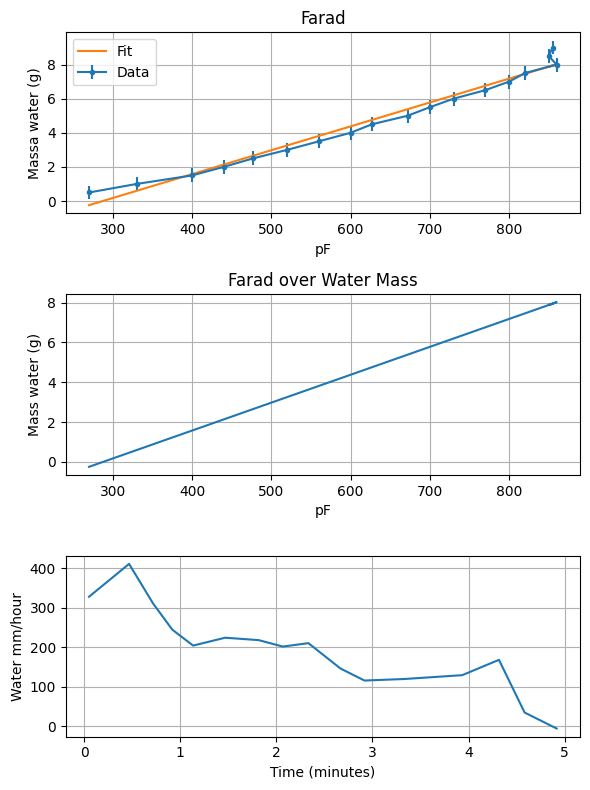

Gem. gevoeligheid: 6.88e-08
Onzekerheid: 0.408 g


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

epsilon0=8.854e-12# permittiviteit van vacuum (F/m)

# Eerste meetreeksen

import numpy as np

# DATA
dml = np.array([
    0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 
    0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5
])

Mass = np.cumsum(dml)/1000

Farad = np.array([
    270, 330, 400, 440, 477, 520, 560, 600, 627, 
    672, 700, 730, 770, 800, 820, 860, 850, 855
])*1e-12

Time = np.array([
    3, 28, 43, 55, 68, 88, 109, 124, 140, 
    160, 175, 200, 236, 259, 275, 295, 362, 385
])
# CONSTANTS
height=0.15# Meter
width=0.10# Meter
thickness=0.005# Meter

Area=height*width

# Epsilon values
eps0=epsilon0
eps_S=eps0*20
eps_W=eps0*80.1# Op kamertemperatuur, K=293

Max_Volume_Constant=0.85# Max percentage that the sponge can be saturated with water

# Setup values
C_ref=100e-12# Reference condensator in F
V_ref=5# Reference input voltage in V

def FaradToVolatge(Farad):
    return (Farad*V_ref)/(Farad+C_ref)

Voltages=FaradToVolatge(Farad)

# CALCULATE THE RIGHT FIT
def VoltageMassFit(Voltage,eps_S_fit,thickness_fit):    # Calculates amount of water present in the sponge
    Volume_fit=Area*thickness_fit
    Mass_max_water_fit=Volume_fit*1000*Max_Volume_Constant  # Maximum mass of water sponge can take on

    term1=Mass_max_water_fit/(Max_Volume_Constant*eps_W)
    term2=(thickness_fit/Area)*((Voltage*C_ref)/(V_ref-Voltage))-(eps_S_fit*epsilon0)

    mass=term1*term2
    return mass

lower_bounds=[1,0.001]
upper_bounds=[100,0.01]

popt,pcov=curve_fit(VoltageMassFit,Voltages,Mass,p0=[20,0.005],bounds=(lower_bounds,upper_bounds))

def VoltageFarad(Voltages):
    Farad=(Voltages*C_ref)/(V_ref-Voltages)
    return Farad

# Calculating rate of change
Top_Area=width*thickness
dt=int(2)# Measurements

Masses=VoltageMassFit(Voltages,*popt)

def mm_water(d_Mass):
    return (d_Mass/Top_Area)

# Calculate mass differences between points
dMass=np.zeros(len(Masses)-dt)
for index in range(len(Masses)-dt):# Calculates difference in mass between two points
    dMass[index]=Masses[index+dt]-Masses[index]

dTimes=np.zeros(len(Time)-dt)
for index in range(len(Time)-dt):
    dTimes[index]=Time[index+dt]-Time[index]

# dTimes is in seconds, convert to hours:
dTimesH=dTimes/3600
percipitation_mm=mm_water(dMass)

# Percipitation in mm/h
water_rate=percipitation_mm/dTimesH


# Onzekerheid:
residuals=Mass-VoltageMassFit(Voltages,*popt)
sigma_mass=np.sqrt(np.mean(residuals**2))

# PLOTTING (Consolidated)
fig2,(ax1,ax2, ax3)=plt.subplots(3,1,figsize=(6,8))

ax1.errorbar(Farad*10e11,Mass*1000,yerr=sigma_mass*1000,fmt='o-',markersize=3,label='Data')
ax1.plot(Farad*10e11,VoltageMassFit(Voltages,*popt)*1000,label='Fit')
ax1.set_title('Farad')
ax1.set_xlabel('pF')
ax1.set_ylabel('Massa water (g)')
ax1.grid(True)
ax1.legend()

ax2.plot(VoltageFarad(Voltages)*10e11,Masses*1000)
ax2.set_title('Farad over Water Mass')
ax2.set_xlabel("pF")
ax2.set_ylabel("Mass water (g)")
ax2.grid(True)

ax3.plot(Time[:-dt]/60,water_rate)
ax3.set_xlabel('Time (minutes)')
ax3.set_ylabel('Water mm/hour')
ax3.grid(True)

plt.tight_layout()
plt.show()

# Some additional computations:
gevoeligheid = (Farad[-1]-Farad[0])/(Mass[-1]-Mass[0])
print(f"Gem. gevoeligheid: {gevoeligheid:.2e}")

residuals = Mass-VoltageMassFit(Voltages, *popt)
uncertainty = np.sqrt(np.mean(residuals**2))
print(f"Onzekerheid: {(uncertainty*1000):.3f} g")

##### De piek zichtbaar aan het einde van de metingen (Rond 800 Farad) is een resultaat van de saturatie van de gebruikte spons. Op dit punt is de hoeveelheid water die aan de onderkant ontsnapt gelijk of groter dan het water wat wordt toegevoegd, of de spons kon simpelweg niet meer water opnemen. \\
##### Daarnaast: Het viel binnen de verwachtingen dat de dielektrische permitiviteit niet equivalent is in beide metingen. De spons was tussen meting 1 en 2 in de magnetron gegaan om de meting opnieuw te kunnen doen - dit had de spons nog droger gemaakt dan waarmee we oorspronkelijk begonnen.

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 400 |4 |
| gemiddelde capaciteit| 2700 | 13.2 |
| maximale capaciteit| 5000 |14.0 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](foto1ontwerp1.png)
![meting 2](Foto2ontwerp1.png)

## Opdracht 7: Plot de kalibratiegrafiek.

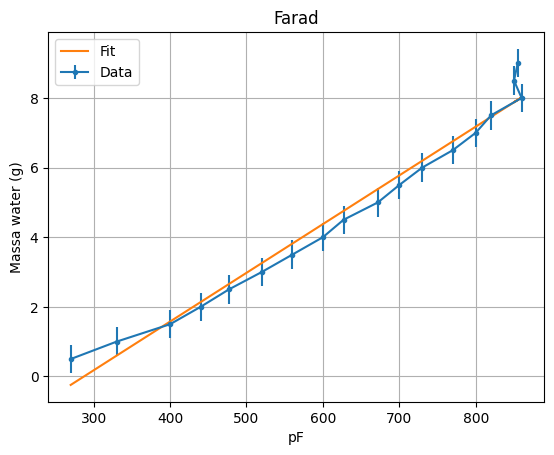

In [3]:
plt.figure()
plt.errorbar(Farad*10e11,Mass*1000,yerr=sigma_mass*1000,fmt='o-',markersize=3,label='Data')
plt.plot(Farad*10e11,VoltageMassFit(Voltages,*popt)*1000,label='Fit')
plt.title('Farad')
plt.xlabel('pF')
plt.ylabel('Massa water (g)')
plt.grid(True)
plt.legend()


## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen:
* Een spons met exactere afmetingen, en een voor-bepaalde dielektrische permitiviteit zodat dit niet onderdeel is van de fit.
* Het water verdelen over heel de spons, in plaats van te druppelen op een enkele plek

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](tudelftLogo.png)

In [7]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

## Opdracht 10: Vul hieronder de conclusie in.

De sensor lijkt geschikt te zijn voor de bedoelde functie van de hoeveelheid mm/uur regen te meten. 
De gebruikte voorspelling maakte ook gebruik van een fit voor de relatieve permitiviteit van de spons - en fit de data goed. We wisten dat er een mogelijke saturatiewaarde was van het water, maar deze hadden we niet in de farad-massa formule gestopt waardoor het daar niet compleet klopte. We konden hierbij ook niet rekening houden met het waterverlies aan de onderzijde van de spons. Dit is echter op te lossen als we een reeks metingen hadden op specifieke mm/h niveaus.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

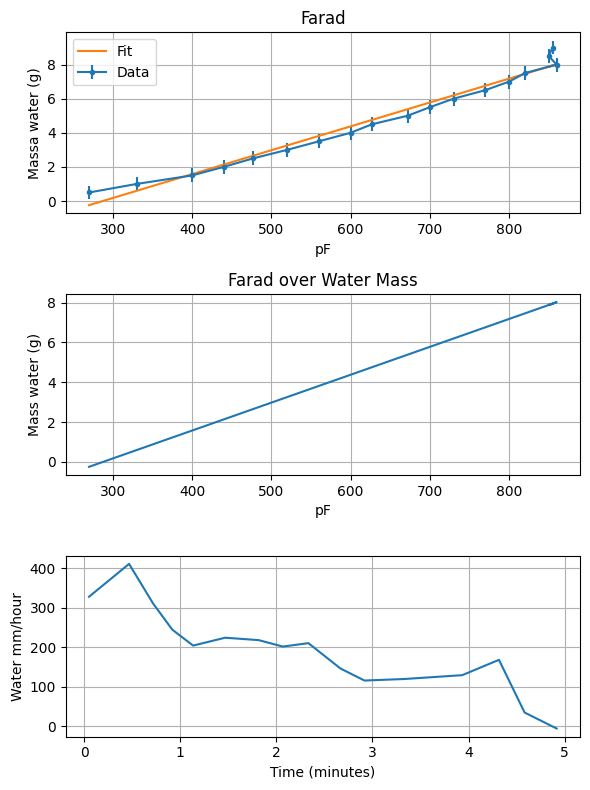

Gem. gevoeligheid: 6.88e-08
Onzekerheid: 0.408 g


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

epsilon0=8.854e-12# permittiviteit van vacuum (F/m)

# Eerste meetreeksen

import numpy as np

# DATA
dml = np.array([
    0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 
    0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5
])

Mass = np.cumsum(dml)/1000

Farad = np.array([
    270, 330, 400, 440, 477, 520, 560, 600, 627, 
    672, 700, 730, 770, 800, 820, 860, 850, 855
])*1e-12

Time = np.array([
    3, 28, 43, 55, 68, 88, 109, 124, 140, 
    160, 175, 200, 236, 259, 275, 295, 362, 385
])
# CONSTANTS
height=0.15# Meter
width=0.10# Meter
thickness=0.005# Meter

Area=height*width

# Epsilon values
eps0=epsilon0
eps_S=eps0*20
eps_W=eps0*80.1# Op kamertemperatuur, K=293

Max_Volume_Constant=0.85# Max percentage that the sponge can be saturated with water

# Setup values
C_ref=100e-12# Reference condensator in F
V_ref=5# Reference input voltage in V

def FaradToVolatge(Farad):
    return (Farad*V_ref)/(Farad+C_ref)

Voltages=FaradToVolatge(Farad)

# CALCULATE THE RIGHT FIT
def VoltageMassFit(Voltage,eps_S_fit,thickness_fit):    # Calculates amount of water present in the sponge
    Volume_fit=Area*thickness_fit
    Mass_max_water_fit=Volume_fit*1000*Max_Volume_Constant  # Maximum mass of water sponge can take on

    term1=Mass_max_water_fit/(Max_Volume_Constant*eps_W)
    term2=(thickness_fit/Area)*((Voltage*C_ref)/(V_ref-Voltage))-(eps_S_fit*epsilon0)

    mass=term1*term2
    return mass

lower_bounds=[1,0.001]
upper_bounds=[100,0.01]

popt,pcov=curve_fit(VoltageMassFit,Voltages,Mass,p0=[20,0.005],bounds=(lower_bounds,upper_bounds))

def VoltageFarad(Voltages):
    Farad=(Voltages*C_ref)/(V_ref-Voltages)
    return Farad

# Calculating rate of change
Top_Area=width*thickness
dt=int(2)# Measurements

Masses=VoltageMassFit(Voltages,*popt)

def mm_water(d_Mass):
    return (d_Mass/Top_Area)

# Calculate mass differences between points
dMass=np.zeros(len(Masses)-dt)
for index in range(len(Masses)-dt):# Calculates difference in mass between two points
    dMass[index]=Masses[index+dt]-Masses[index]

dTimes=np.zeros(len(Time)-dt)
for index in range(len(Time)-dt):
    dTimes[index]=Time[index+dt]-Time[index]

# dTimes is in seconds, convert to hours:
dTimesH=dTimes/3600
percipitation_mm=mm_water(dMass)

# Percipitation in mm/h
water_rate=percipitation_mm/dTimesH


# Onzekerheid:
residuals=Mass-VoltageMassFit(Voltages,*popt)
sigma_mass=np.sqrt(np.mean(residuals**2))

# PLOTTING (Consolidated)
fig2,(ax1,ax2, ax3)=plt.subplots(3,1,figsize=(6,8))

ax1.errorbar(Farad*10e11,Mass*1000,yerr=sigma_mass*1000,fmt='o-',markersize=3,label='Data')
ax1.plot(Farad*10e11,VoltageMassFit(Voltages,*popt)*1000,label='Fit')
ax1.set_title('Farad')
ax1.set_xlabel('pF')
ax1.set_ylabel('Massa water (g)')
ax1.grid(True)
ax1.legend()

ax2.plot(VoltageFarad(Voltages)*10e11,Masses*1000)
ax2.set_title('Farad over Water Mass')
ax2.set_xlabel("pF")
ax2.set_ylabel("Mass water (g)")
ax2.grid(True)

ax3.plot(Time[:-dt]/60,water_rate)
ax3.set_xlabel('Time (minutes)')
ax3.set_ylabel('Water mm/hour')
ax3.grid(True)

plt.tight_layout()
plt.show()

# Some additional computations:
gevoeligheid = (Farad[-1]-Farad[0])/(Mass[-1]-Mass[0])
print(f"Gem. gevoeligheid: {gevoeligheid:.2e}")

residuals = Mass-VoltageMassFit(Voltages, *popt)
uncertainty = np.sqrt(np.mean(residuals**2))
print(f"Onzekerheid: {(uncertainty*1000):.3f} g")

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

![meting 1](foto1ontwerp1.png)
![meting 2](Foto2ontwerp1.png)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

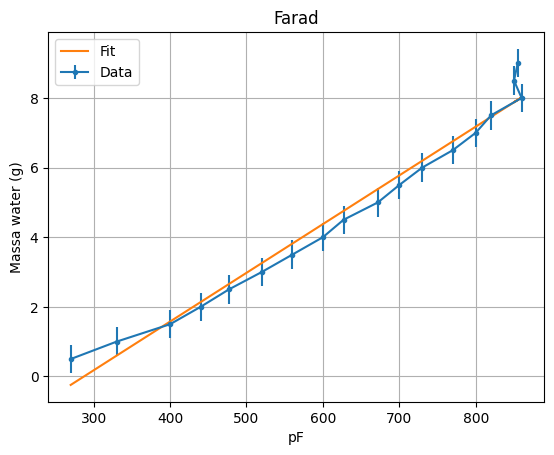

Gem. gevoeligheid: 6.88e-08
Onzekerheid: 0.408 g


In [4]:
plt.figure()
plt.errorbar(Farad*10e11,Mass*1000,yerr=sigma_mass*1000,fmt='o-',markersize=3,label='Data')
plt.plot(Farad*10e11,VoltageMassFit(Voltages,*popt)*1000,label='Fit')
plt.title('Farad')
plt.xlabel('pF')
plt.ylabel('Massa water (g)')
plt.grid(True)
plt.legend()

plt.show()

# Some additional computations:
gevoeligheid = (Farad[-1]-Farad[0])/(Mass[-1]-Mass[0])
print(f"Gem. gevoeligheid: {gevoeligheid:.2e}")

residuals = Mass-VoltageMassFit(Voltages, *popt)
uncertainty = np.sqrt(np.mean(residuals**2))
print(f"Onzekerheid: {(uncertainty*1000):.3f} g")

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 400 |4 |
| gemiddelde capaciteit| 2700 | 13.2 |
| maximale capaciteit| 5000 |14.0 |